<a href="https://colab.research.google.com/github/SakinaE/Deep-learning-Neural-networks/blob/main/Image_classification_D%26N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


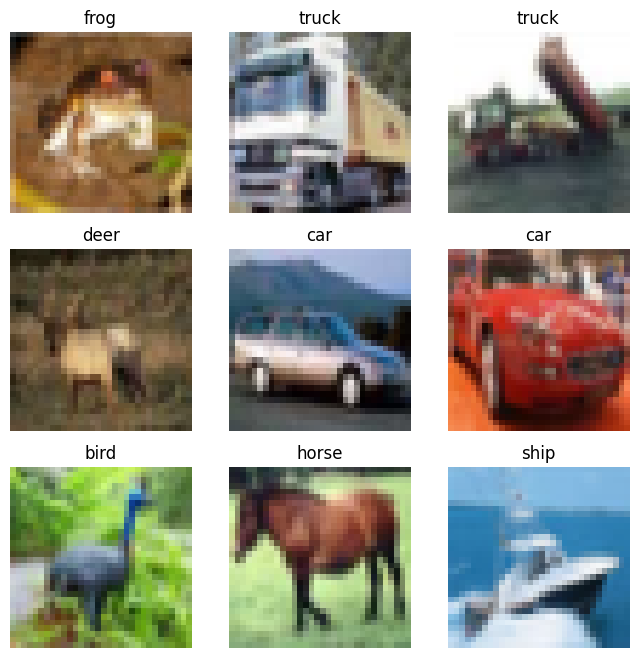

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 115s 71ms/step - accuracy: 0.3779 - loss: 1.6949 - val_accuracy: 0.4977 - val_loss: 1.3536
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - accuracy: 0.4988 - loss: 1.3878 - val_accuracy: 0.5721 - val_loss: 1.1779
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.5539 - loss: 1.2634 - val_accuracy: 0.5962 - val_loss: 1.1407
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.5816 - loss: 1.1848 - val_accuracy: 0.6343 - val_loss: 1.0334
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 63ms/step - accuracy: 0.6026 - loss: 1.1344 - val_accuracy: 0.6097 - val_loss: 1.1144
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.6212 - loss: 1.0812 - val_accuracy: 0.6536 - val_loss: 0.9816
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 63ms/step - accuracy: 0.6347 - loss: 1.0449 - val_accuracy: 0.6634 - val_loss: 0.9485
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.

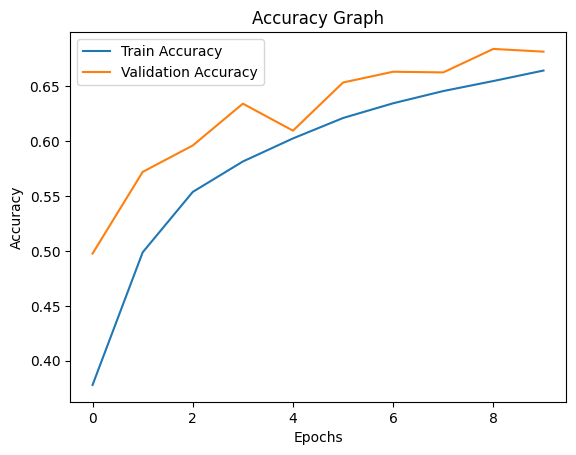

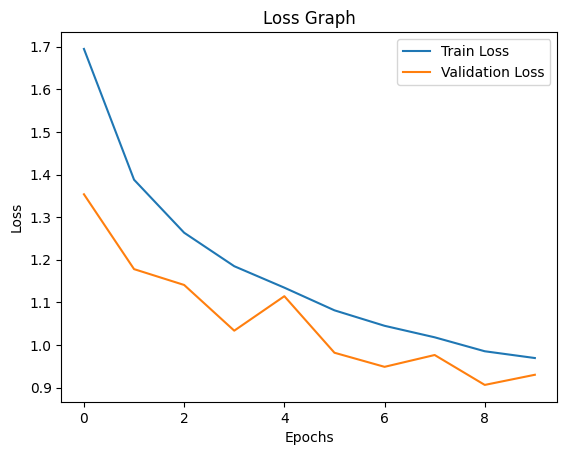

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Predicted Class: truck
Confidence: 0.681139

Business Insight:
This model can be used in:
- Traffic monitoring systems
- Automated surveillance
- Retail product classification
- Smart city applications


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0

class_names = ['airplane','car','bird','cat','deer',
               'dog','frog','horse','ship','truck']


plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()


datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train)

model = models.Sequential()


model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))


model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test)
)


test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

img = cv2.imread("/content/test traffic.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (32,32))
img = img / 255.0

img = np.reshape(img, (1,32,32,3))

prediction = model.predict(img)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)


print("\nBusiness Insight:")
print("This model can be used in:")
print("- Traffic monitoring systems")
print("- Automated surveillance")
print("- Retail product classification")
print("- Smart city applications")